# Lab 4
Simeng Zhang


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

### Q1.
1. Set up a grid of $K$ equally spaced values between 0 and 1, `{1/K, 2/K, ..., K/K}`.
2. Draw a point from the grid at random with equal probability.
3. For a very small $K$, repeat the above process `n = 5_000` times, and plot the ECDF of the draws.
4. What distribution does this approach as you increase $K$?

### Answer:

As $K$ increases, the grid becomes denser and the ECDF approaches the CDF of a continuous Uniform(0, 1) distribution. 

In [11]:
K = 5
n = 5_000

grid = np.arange(1, K + 1) / K
grid

array([0.2, 0.4, 0.6, 0.8, 1. ])

In [12]:
draws = np.random.choice(grid, size=n)
draws[:10]

array([1. , 0.8, 0.8, 0.6, 0.8, 1. , 0.8, 0.2, 0.4, 1. ])

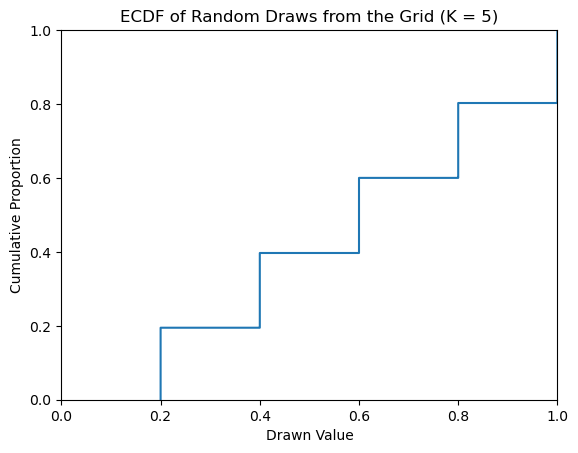

In [13]:
sns.ecdfplot(x=draws)

plt.xlabel("Drawn Value")
plt.ylabel("Cumulative Proportion")
plt.title(f"ECDF of Random Draws from the Grid (K = {K})")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

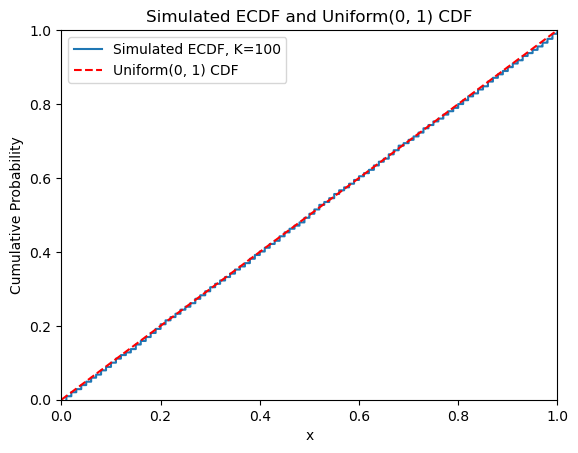

In [14]:
K = 100

grid = np.arange(1, K + 1) / K
draws = np.random.choice(grid, size=n)

x = np.linspace(0, 1, 1_000)

sns.ecdfplot(
    x=draws,
    label=f"Simulated ECDF, K={K}"
)

plt.plot(
    x,
    stats.uniform.cdf(x, loc=0, scale=1),
    color="red",
    linestyle="--",
    label="Uniform(0, 1) CDF"
)

plt.xlabel("x")
plt.ylabel("Cumulative Probability")
plt.title("Simulated ECDF and Uniform(0, 1) CDF")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.show()

### Q2.

We often study sample averages: It's one of the first statistics you calculate for any dataset. What is the distribution of the sample mean?

1. Draw `n = 32` values from `Uniform[-sqrt(3), sqrt(3)]`; these are your data. The choice of $\pm \sqrt{3}$ ensures each draw has mean 0 and variance 1.
2. For this sample, compute the mean and multiply by `np.sqrt(n)`.
3. Repeat the above process `b = 5_000` times and plot the ECDF.
4. What distribution does this approach as $n$ increases?


### Answer:

The simulated ECDF is close to the CDF of a standard normal distribution.  
As $n$ increases, $\sqrt{n}\bar{X}$ approaches $N(0,1)$.

In [16]:
n = 32
b = 5_000

scaled_means = []

for i in range(b):
    sample = np.random.uniform(
        low=-np.sqrt(3),
        high=np.sqrt(3),
        size=n
    )
    
    sample_mean = np.mean(sample)
    scaled_mean = np.sqrt(n) * sample_mean
    
    scaled_means.append(scaled_mean)

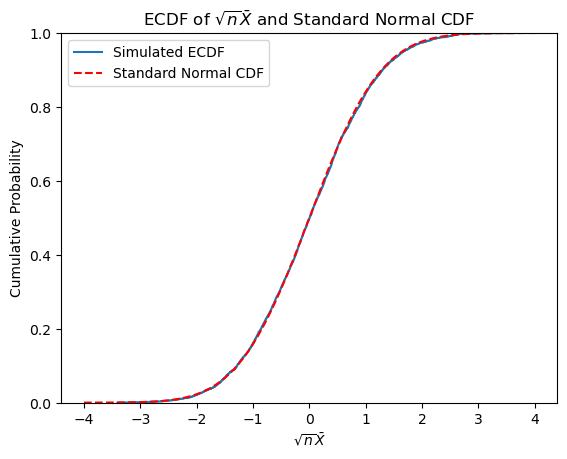

In [61]:
x = np.linspace(-4, 4, 1_000)

sns.ecdfplot(
    x=scaled_means,
    label="Simulated ECDF"
)

plt.plot(
    x,
    stats.norm.cdf(x, loc=0, scale=1),
    color="red",
    linestyle="--",
    label="Standard Normal CDF"
)

plt.xlabel(r"$\sqrt{n}\bar{X}$")
plt.ylabel("Cumulative Probability")
plt.title(r"ECDF of $\sqrt{n}\bar{X}$ and Standard Normal CDF")
plt.legend()
plt.show()

### Q3.

In reliability engineering, we are often concerned with the proportions of failures that occur. For example, the Challenger space shuttle exploded on January 28, 1986, when the primary and secondary o-rings failed. Floods often occur because too many levees or pumps are compromised. In this simulation, we have 40 units that each fail with probability $p$, and we want to study the distribution of the survivors. 

1. Flip `n = 40` coins, which each come up heads with probability $p = 1/2$ and tails with complementary probability.
2. From the final count of heads, subtract the expected number of heads, `n * p`.
3. Divide by the standard deviation `sqrt( n * p * (1-p) )`.
4. Repeat the above process `b = 5_000` times and plot the ECDF.
5. What distribution does this approach as $n$ increases?
6. How do the results change as you adjust $p$?

### Answer:

When $p=0.5$, the distribution is approximately symmetric and closest to the standard normal distribution. When $p=0.9$, it is left-skewed, while for $p=0.05$, it is right-skewed. As $p$ moves away from $0.5$, the distribution becomes more skewed and the normal approximation becomes worse.

In [62]:
n = 40
p = 0.5
b = 5_000

heads = np.random.binomial(
    n=n,
    p=p,
    size=b
)

standardized_heads = (
    heads - n * p
) / np.sqrt(n * p * (1 - p))


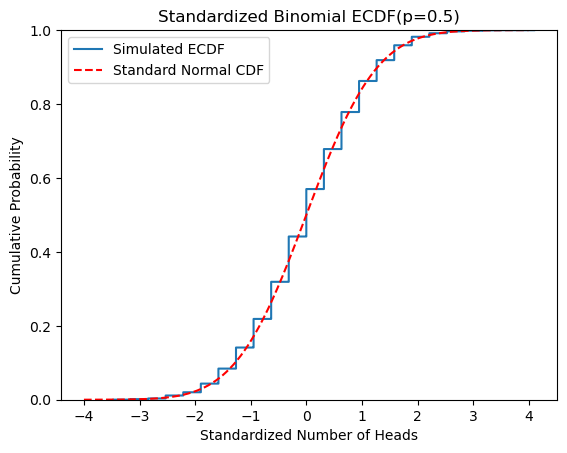

In [63]:
x = np.linspace(-4, 4, 1_000)

sns.ecdfplot(
    x=standardized_heads,
    label="Simulated ECDF"
)

plt.plot(
    x,
    stats.norm.cdf(x, loc=0, scale=1),
    color="red",
    linestyle="--",
    label="Standard Normal CDF"
)

plt.xlabel("Standardized Number of Heads")
plt.ylabel("Cumulative Probability")
plt.title("Standardized Binomial ECDF(p=0.5)")
plt.legend()
plt.show()

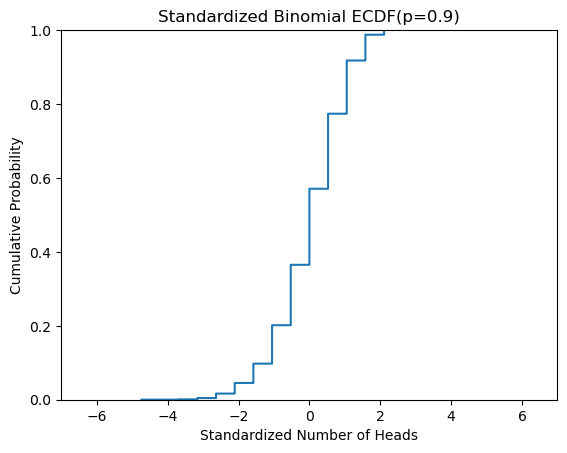

In [51]:
n = 40
p = 0.9
b = 5_000

heads = np.random.binomial(
    n=n,
    p=p,
    size=b
)

standardized_heads = (
    heads - n * p
) / np.sqrt(n * p * (1 - p))

x = np.linspace(-4, 4, 1_000)

sns.ecdfplot(
    x=standardized_heads,
    label="Simulated ECDF"
)

plt.xlabel("Standardized Number of Heads")
plt.ylabel("Cumulative Probability")
plt.title("Standardized Binomial ECDF(p=0.9)")
plt.xlim(-7, 7)
plt.show()


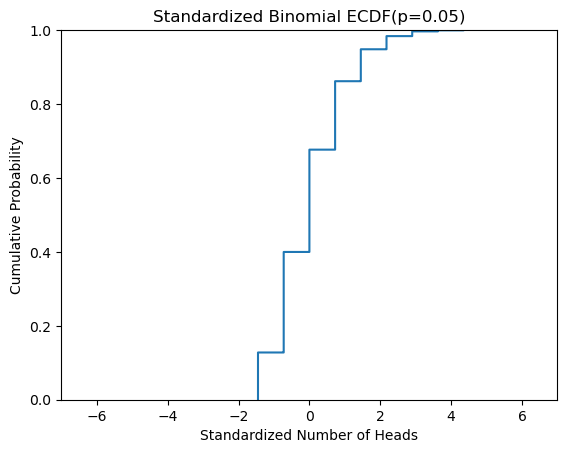

In [53]:
n = 40
p = 0.05
b = 5_000

heads = np.random.binomial(
    n=n,
    p=p,
    size=b
)

standardized_heads = (
    heads - n * p
) / np.sqrt(n * p * (1 - p))

x = np.linspace(-4, 4, 1_000)

sns.ecdfplot(
    x=standardized_heads,
    label="Simulated ECDF"
)

plt.xlabel("Standardized Number of Heads")
plt.ylabel("Cumulative Probability")
plt.title("Standardized Binomial ECDF(p=0.05)")
plt.xlim(-7, 7)
plt.show()


### Q4.

A process is running in discrete time. In each time interval of length `dt`, it terminates with probability `r * dt`, where `r * dt < 1`. This is called an arrival, death, or survival process, and is popular for modeling how long patients live after a procedure, whether an employee quits, or the arrival of the next goal in a sportsball match.

1. For each simulation of the process, determine the period in which termination occurs.
2. Convert periods to time by multiplying by `dt`.
3. Repeat the simulation `n = 5_000` times and plot the ECDF, for a value of `dt` close to zero (e.g. `dt = 1e-3`).
4. What distribution does this approach as $dt$ goes to zero?
5. How do the results change as you adjust $r$?

### Answer:

As $dt$ approaches zero, the termination time approaches an exponential distribution with rate $r$. A larger $r$ increases the probability of termination in each time interval, resulting in shorter waiting times and shifting the ECDF to the left. While a smaller $r$ produces longer waiting times.

In [54]:
dt = 1e-3
r = 1
n = 5_000

periods = np.random.geometric(
    p=r * dt,
    size=n
)

termination_times = periods * dt

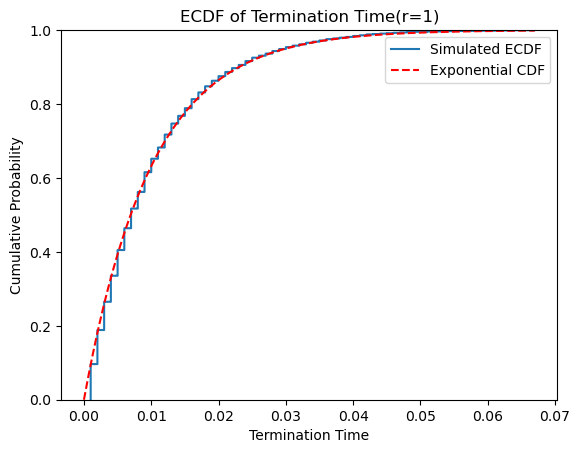

In [60]:
x = np.linspace(
    0,
    np.max(termination_times),
    1000
)

sns.ecdfplot(
    x=termination_times,
    label="Simulated ECDF"
)

plt.plot(
    x,
    stats.expon.cdf(x, scale=1/r),
    color="red",
    linestyle="--",
    label="Exponential CDF"
)

plt.xlabel("Termination Time")
plt.ylabel("Cumulative Probability")
plt.title("ECDF of Termination Time(r=1)")
plt.legend()
plt.show()

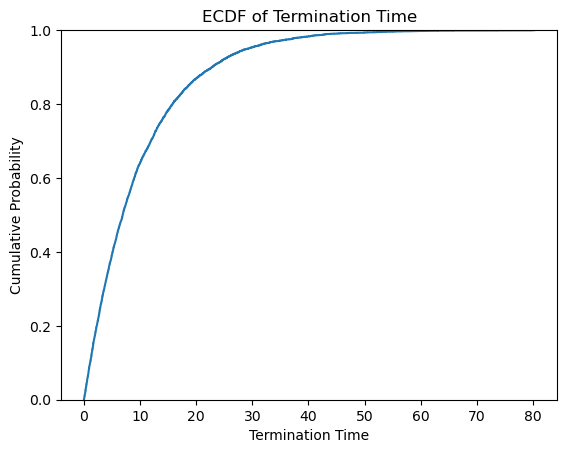

In [ ]:
dt = 1e-3
r = 0.1
n = 5_000

periods = np.random.geometric(
    p=r * dt,
    size=n
)

termination_times = periods * dt

x = np.linspace(
    0,
    np.max(termination_times),
    1000
)

sns.ecdfplot(
    x=termination_times,
)

plt.xlabel("Termination Time")
plt.ylabel("Cumulative Probability")
plt.title("ECDF of Termination Time(r=0.1)")
plt.show()

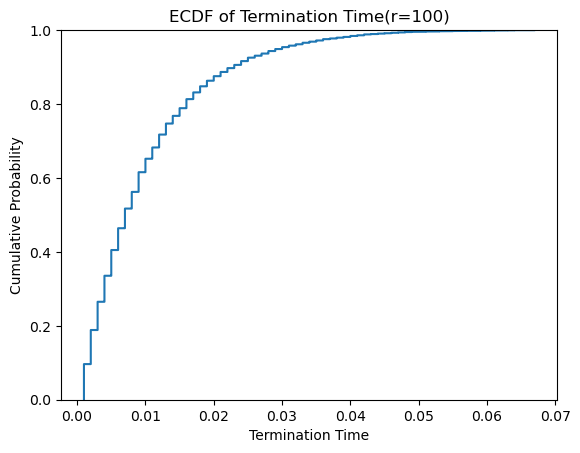

In [59]:
dt = 1e-3
r = 100
n = 5_000

periods = np.random.geometric(
    p=r * dt,
    size=n
)

termination_times = periods * dt

x = np.linspace(
    0,
    np.max(termination_times),
    1000
)

sns.ecdfplot(
    x=termination_times,
)

plt.xlabel("Termination Time")
plt.ylabel("Cumulative Probability")
plt.title("ECDF of Termination Time(r=100)")
plt.show()